# Introduction
The goal of this blog post is to introduce the idea of the RSA cryptosystem. RSA is an example of _asymmetric encryption_; this concept is critical to understand SSH, digital signatures, and the blockchain. To understand what this means, let's first look at an example of _symmetric encryption_ to motivate why asymmetry is useful.

## Encryption

<p align="center">
  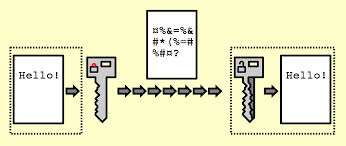
</p>

(Image Source: [Encryption - Wikipedia](https://en.wikipedia.org/wiki/Encryption))

Suppose that two people, $A$ and $B$ that want to send each other messages. However, since they're paranoid that other people might read their messages, they agree on a way to scramble their message to a format that only they know how to unscramble; this process is known as _encryption_.

## Symmetric cryptopgraphy 

In symmetric cryptography, the process of unscrambling the message is simply the inverse of the process for scrambling it. Let $M$ represent our message, $C$ represent our encrypted message, and $f$ be our scrambling function, then in symmetric encryption we have that $C = f(M)$ and $M = f^{-1}(C)$. To understand this, let's the typical example: _the Caesar Cipher_.

### Example: Caesar  Cipher


<p align="center">
  <img src="https://consoleflare.com/blog/wp-content/uploads/2024/03/image-1-1024x480.png" />
</p>

(Image Source: [Empowering Encryption: Mastering the Caesar Cipher in 3 powerful Steps](https://consoleflare.com/blog/the-caesar-cipher-an-encryption-technique/))

The Caesar Cipher, named after Julius Caesar, is a very simple cipher where each letter in the plain text is shifted over by some fixed number of positions $k$ in the alphabet. This shift is known as the *key*. As a super simple example, let's set $k=1$. In this setting, the letter A is replaced with B, B is replaced with C, C is replaced with D, and so on, until we reach the Z, which is replaced with A. Using our notation from above, to shift a message $M$ by $k$ letters we get the encrypted message $C = f(M, k)$. Let's write some code to do this:

Let's start by getting a list of the entire English alphabet:

In [2]:
import string
ALPHABET  = list(string.ascii_uppercase)
ALPHABET[0:3]

['A', 'B', 'C']

Now we need a way to get the index of a letter given the alphabet. Here we will use Python's built-in `index` method. Note that there are much more efficient ways to do this (eg. using ASCII codes), but the focus here is on the concept of a symmetric cipher, rather than efficiency.

In [3]:
def get_index(letter):
    return ALPHABET.index(letter)

get_index("A")

0

Next, let's write a function that calculates the _new_ letter given the shift $k$. This is our scrambling function, so I will denote is as $s$:

In [17]:
def f(letter, k):
    index = get_index(letter)
    new_index = (index + k) % len(ALPHABET)
    return ALPHABET[new_index]

f("A", 1) # every A is replaced with a B

'B'

We can also write a function that gives the original letter back, given the encrypted letter and the shift. Since this is the inverse of the scrambling function we will denote this as $s^{-1}$:

In [18]:
def f_inv(letter, k):
    index = get_index(letter)
    return ALPHABET[(index - k) % len(ALPHABET)]

f_inv("B", 1) # every B was originally an A

'A'

Now that we have defined all these functions, we can easily encipher and decipher entire sentences using $s$ and $s^{-1}$, respectively:

In [19]:
def translate(k, M, func):
    e = ""
    for char in M:
        # Skip characters that aren't letters
        if not char.isalpha():
            e += char
            continue
        # Convert and cast back to lower case, if needed
        new_letter = func(char.upper(), k).lower() if char.islower() else func(char.upper(), k)
        e += new_letter
        
    return e

m = "Hello world!"
e = translate(2, m, f)
d = translate(2, e, f_inv)
print(f"Original message: {m}\nEnciphered message: {e}\nDeciphered message: {d}")

Original message: Hello world!
Enciphered message: Jgnnq yqtnf!
Deciphered message: Hello world!


The key point to emphasize is that the enciphering and deciphering processes are the same, just in one case we use $s$ to swap letters, and in the other case we use $s^{-1}$. In both cases, each party just needs to know the shift parameter $k$. In this sense, they both know the exact same information, and hence the encryption is _symmetric_.

## Asymmetric encryption 

In cryptography, a *key* is a piece of information that allows you to encode and decode your message. In the Caesar Cipher, the key was simply the shift, $k$, but in general the key can be a lot more complex. The main problem in symmetric encryption is that somehow both parties need to agree on a key; to do this, they must somehow communicate with each other. This can be problematic, however. For example, suppose it was impossible or impractical to communicate the key (eg. they don't trust any existing communication methods and they live too far away from each other to meet up in person to discuss it). This is known as the *key distribution problem*, and it's the reason that symmetric encryption is often insufficient. This problem led to research into a new form of encryption, known as _asymmetric encryption_. In _asymmetric encryption_, different keys are used for encryption and decryption, and hence the knowledge of each party is _asymmetric_. This distinction is often made clearer via an analogy with padlocks:

### Padlocks: Symmetric

Alice and Bob decide that they will communicate through the mail by sending each other messages that are locked in an iron box. They share a single iron box with a lock, and each has a an identical set of keys. Importantly, the lock cannot simply be snapped shut; you must use the key for both locking and unlocking. To send a message, Alice writes a message on paper, puts it in the box, closes the lock using her key, and sends it in the mail. To respond, Bob must open the lock with his key, then he can read the message, write a response, close the lock with his key, and send it back. In this setup, *both parties use the same key* to lock and unlock the box (encrypt and decrypt).

<div class="alert alert-block alert-danger">
<b>Problem</b>

If someone steals or copies the key during exchange, they can read or tamper with the message. That’s why symmetric encryption requires secure key exchange first (this is the key distribution problem from earlier).
</div>

### Padlocks: Asymmetric

In our new scenario, let's imagine that Alice has a special padlock that anyone can close (so it can be closed without a key), but only she has the key to open. Here, you can go to the store and buy an "Alice lock" that is already open, and you can close it by snapping it shut, but once it's shut only Alice can open it. Now, Bob wants to send a message to Alice, he can go to the store, buy an "Alice lock", write his message, put it in a box, lock it with an "Alice lock", and he can be sure that the only person that can open it is Alice. To respond, Alice does the same, except this time she locks the box with a "Bob lock". In asymmetric encryption, the lock is called a *public key* and the keys are called *private keys*.

![](https://upload.wikimedia.org/wikipedia/commons/d/d8/Asymmetric_encryption_padlock_analogy.svg)

(Image Source: [Asymmetric encryption padlock analogy](https://www.google.com/url?sa=i&url=https%3A%2F%2Fcommons.wikimedia.org%2Fwiki%2FFile%3AAsymmetric_encryption_padlock_analogy.svg&psig=AOvVaw0ZKTqB805zHZkFHNqE2XNj&ust=1752687599350000&source=images&cd=vfe&opi=89978449&ved=0CBgQjhxqFwoTCKDBxaC0v44DFQAAAAAdAAAAABAd))

<div class="alert alert-block alert-success">
<b>Upshot</b>

Notice that the key didn't need to be distributed; Alice designs her own key and only needs to send people the lock (which isn't dangerous in any way).
</div>

Notice that someone might be able to buy an Alice lock and reverse engineer it to build their own Alice key and intercept all her messages; it turns out that in asymmetric cryptography, this is also true, but we try to design the locks to be as difficult to reverse engineer as possible. In the real world, we deal with numbers instead of keys and locks, and we can design asymmetric encryption systems that are extremely unlikely (but not impossible) to crack. Putting this into mathematical terms, Alice's public key will give us the parameters for the public key function $C = f_A(M, \text{public key})$ used to encrypt messages $M$ sent to Alice, and Alice's private key gives the parameters for the private key function $f^{-1}_A$ that allows her to decrypt messages as $M = f^{-1}_A(C, \text{private key})$. Our desiderata for $f_A$ are:

1. Encoding is easy
2. Decoding is very difficult for eavesdroppers
3. Decoding is easy if you have the private key

One popular example is known as *RSA encryption*.

### Example: RSA Encryption
In RSA encryption, named after its creators (Rivest-Shamir-Adleman), a *public key* consists of a pair of numbers $(n,e)$ that parameterize the public key function and the *private key* is the number $d$ which parameterize the private key function. These numbers are selected via *key generation*. The processes for generating these keys and using them in encryption/decryption were constructed such that the probability of guessing the private key and succesfully deciphering a message is extremely low. This leads to some of the math getting a little bit nasty, so just try to follow the key ideas in the process rather than every detail.

#### Sample Encryption and Decryption

It's important to note that RSA works with numbers, not text (at least not directly). For our simplest example, we will assume Bob's message $M$ is simply a number; later, we will see how text can be converted to a number to be encrypted. In RSA we have that:

- $f_A(M, (n,e)) = M^{e} (\text{mod } n)$
- $f_A^{-1}(C, d) = C^{d} (\text{mod } n)$

1. For Bob to send a message to Alice, he first looks up her public key: $(n,e)$. To encrypt a message $M$, we compute it as $C = M^{e} (\text{mod } n)$, where $C$ is the encrypted message. 
2. To decrypt a message, Alice uses her private key $d$: $M = C^{d} (\text{mod } n).$

As an example, let's assume the following:
- $n =33$
- $e$ = 7
- $d = 3$
- $M = 5$

![](../../assets/img/rsa.png)

We will write some code to test this out:

In [20]:
n = 33
e = 7
d = 3
M = 5

def encrypt(M, n, e):
    C = M**e % n
    return C

def decrypt(C, n, d):
    M = C**d % n
    return M

C = encrypt(M, n, e)
M_d = decrypt(C, n, d)

print(f"Original message: {M}\nEncrypted message: {C}\nDecrypted message: {M_d}")

Original message: 5
Encrypted message: 14
Decrypted message: 5


The essential part of this formulation is that for an eavesdropper to decrypt the message, they need to solve for the private key $d$ which inverts the encryption. Mathematically, this is the value $d$ that satisfies:

$$(M^e)^d \equiv M (\text{mod } n)$$

It turns out that solving for $d$ is a computationally hard problem for which no efficient algorithm is known. This brings us to our next question: **how do we generate $e$ and $d$ such that...**
1. The equation above holds for our choice of $e$ and $d$
2. It's difficult for an eavesdropper to compute $d$

#### Key generation

First, note that $n$ in the public key is selected such that $n=pq$ for two large prime numbers $p$ and $q$; *these primes are kept secret, but are not actually part of the private key*.

**Goal**: Given $n=pq$, generate pair $(e,d)$ such that 

$$(M^e)^d \equiv M^{ed} \equiv M (\text{mod } n)$$

Here is the general idea of how we will accomplish this:
1. We will use Carmichael's function to get an equation of the form $M^{\lambda(n)} = 1 (\text{mod } n)$ (the Carmichael function is explained below)
2. Raise each side to the power of $v$ to get $M^{v\lambda(n)} \equiv 1^v \equiv 1 (\text{mod } n)$
3. Multiply both sides by $M$ to get $M^{v\lambda(n) + 1} \equiv 1 \times M \equiv M (\text{mod } n)$
4. Solve for $e,d,v$ such that $ed = v\lambda(n) + 1$, then we have $M^{v\lambda(n) + 1} = M^{ed} = M (\text{mod } n)$

Note that this last line can be re-expressed using modular arithmetic:

$$ed = v\lambda(n) + 1 \iff ed \equiv v\lambda(n) + 1 \equiv 1 (\text{mod } \lambda(n))\iff ed \equiv 1 (\text{mod } \lambda(n))$$

Thus, we often re-express the goal of the last line as solving for $e,d$ such that $ed \equiv 1 (\text{mod } \lambda(n))$. In words, $d$ is the *modular multiplicative inverse of $e$* modulo $\lambda(n)$. Keep this in mind, since I will use the goals interchangeably. Now that we have an outline, let's dig deeper into the math.

##### Coprimes and the Euler's Totient Function

Two numbers $a$ and $b$ are said to be *coprime* if their greatest common divisor is 1; that is, the biggest number that divides both $a$ and $b$ is 1. For example, 4 and 9 are coprime, because the divisors of 4 are $\{1,2,4\}$ and the divisors of 9 are $\{1,3,9\}$, so their greatest common divisor is 1. Euler's totient function, $\phi(n)$ is the total number of comprimes of $n$ that are less than $n$. As an example, $\phi(9) = 6$ since the coprimes of 9 that are less than 9 are $\{1,2,4,5,7,8\}$. Notice that if a number $p$ is prime, then $\phi(p) = p-1$. Intuitively, a prime number is, by definition, a number only divisible by 1 and itself, so clearly, every positive integer less than $p$ is coprime with $p$, and there are $p-1$ such numbers.

##### The Carmichael Function

In number theory, the Carmichael function $\lambda(n)$ of some positive integer $n$ is the smallest positive integer such that for every integer $M$ coprime to $n$, we have that

$$M^{\lambda(n)} \equiv 1 (\text{mod } n)$$

The properties of this function will be useful for constructing our encryption scheme. As shown in our outline above, we can now raise this to the power of $v$ and multiply both sides by $M$ to get

$$M^{v\lambda(n) + 1} \equiv M (\text{mod } n)$$

Now want to solve $e,d,v$ such that $ed = v\lambda(n) + 1$. To do this, let's look at the equation for $\lambda(n)$:

$$
\lambda(n) = 
\begin{cases}
\phi(n) & \text{if } n = 1, 2, 4, p^e, \text{ or } 2p^e \text{ for odd prime } p \\
\frac{1}{2} \phi(n) & \text{if } n = 2^e, \, e > 2 \\
\operatorname{lcm}(\lambda(n_1), \lambda(n_2), \dots, \lambda(n_k)) & \text{ if } n = n_1 n_2 \dots n_k \text{ where } n_1,n_2,\dots,n_k \text{ are powers of distinct primes}
\end{cases}
$$

where $\phi(n)$ is the Euler totient function.

The key parts here are the first case and the last case. The first case tells us that for a prime $p$, we have that $\lambda(p) = \phi(p) = p-1$. Combining with the last case we find that if $n=pq$, then $\lambda(n) = \operatorname{lcm}(\lambda(p), \lambda(q)) = \operatorname{lcm}(p - 1, q - 1)$. From here, an efficient algorithm is known to compute $\operatorname{lcm}(p - 1, q - 1)$, which is known as the *Euclidean algorithm*. 

What remains, then, is to solve for $ed \equiv 1 (\text{mod } \lambda(n))$. To do this, we first *choose* $e$ such that $1 < e < \lambda(n)$ and $e$ and $\lambda(n)$ are coprime. We do this because when $e$ and $\lambda(n)$ coprime, an efficient algorithm called the *extended Euclidean algorithm* can be used to solve for $d$. 


##### Recap

Okay... let's recap by reviewing the steps to generate the keys. Our goal was to come up with a process that will help us generate a pair $(e,d)$ such that $M^{ed} = M (\text{mod } n)$, so that we can encrypt our messages using $e$ and decrypt them using $d$. The steps to generate them are:
1. Select two large primes $p$ and $q$ and set $n = pq$
2. Compute $\lambda(n) = \operatorname{lcm}(p - 1, q - 1)$ using the Euclidean algorithm
3. Select $e$ such that $1 < e < \lambda(n)$ and $e$ and $\lambda(n)$ are coprime
4. Solve for $d$ in $ed \equiv 1 (\text{mod } \lambda(n))$ using the *extended Euclidean algorithm*

**Essential takeaway:** For a hacker to solve for $e$, they need to know $\lambda(n)$; to compute $\lambda(n)$ they need $p$ and $q$. It turns out that there are no efficient ways to solve for $p$ and $q$, and if you pick large $p$ and $q$ then it will take an unreasonably long time to find them. 

#### Key Generation in Action

Here I will write some basic code that will allow us to generate keys. **This code should not be used in practice; there are more sophisticated standards for how to choose public and private keys to minimize risk**. In addition, this code trades off efficiency for simplicity and clarity. For this section I won't write any code for generating primes. Instead we will simply choose them ourselves.

In [8]:
from math import lcm, gcd
import random

# Compute lambda(n) = lcm(p-1, q-1)
def carmichael(p,q):
    return lcm(p-1, q-1)

carmichael(7,11)

30

In [9]:
# Generate a random coprime of x
def get_coprime(x):
    coprimes = []
    for c in range(2,x):
        if (gcd(c, x) == 1):
            coprimes.append(c)
    i = random.randint(0, len(coprimes) - 1)
    
    return coprimes[i]

get_coprime(30)

17

In [10]:
def generate_ed(p,q):
    lambda_n = carmichael(p,q)
    e = get_coprime(lambda_n)
    d = pow(e, -1, lambda_n) # computes modular multiplicative inverse
    assert (e*d % lambda_n == 1) # should always be true
    return e,d

e,d = generate_ed(7,11)

We now have everything we need to perform RSA!

In [11]:
p, q = 7, 11
n = p*q
e,d = generate_ed(p,q)
M = 3
C = encrypt(M, n, e)
M_d = decrypt(C, n, d)

print(f"Original message: {M}\nEncrypted message: {C}\nDecrypted message: {M_d}")


Original message: 3
Encrypted message: 59
Decrypted message: 3


#### Using RSA on text
To use RSA on text, we need a way to convert text to an integer for encryption, and a way to convert it back to text when decrypting. **Again, do not use this code in practice**. To keep this example super simple, we will define a mapping between a few messages and integers:

In [21]:
ENCODINGS = [
    ["hello, world", "i'm hungry", "this is a message"],
    [15, 32, 17]
]

def encode(message):
    i = ENCODINGS[0].index(message)
    return ENCODINGS[1][i]

def decode(encoding):
    i = ENCODINGS[1].index(encoding)
    return ENCODINGS[0][i]

#### Putting it all together
We can finally combine all our code together to perform RSA using text!

In [13]:
i = 0
message = ENCODINGS[0][i]
M = ENCODINGS[1][i]
p = 23
q = 41
n = p*q
e,d = generate_ed(p,q)
C = encrypt(M, n, e)
M_d = decrypt(C, n, d)

print(f"Original message: {message}\
    \nEncoded message: {encode(message)}\
    \nEncrypted message: {C}\
    \nDecrypted message: {M_d}\
    \nDecoded decrypted message: {decode(M_d)}")

Original message: hello, world    
Encoded message: 15    
Encrypted message: 88    
Decrypted message: 15    
Decoded decrypted message: hello, world


### Digital Signatures
In addition to using RSA's public and private keys for encryption, they can also be used for *digital signatures*. Digital signature allows for the receiver of a message to verify the sender's identity. We do this by relying on the idea that the public and private key functions are inverses. For Bob to sign a message $M$ he sends to Alice, we do the following:

1. Bob obtains $M'$ using his private key function: $M' = f_B^{-1}(M, \text{Bob private key})$  $f_B^{-1}$
2. Bob obtains $M''$ using Alice's public key function: $M'' = f_A(M', \text{Alice public key})$ 
3. Alice obtains $M'$ using her private key function: $M' = f_A^{-1}(M'', \text{Alice private key})$
4. Alice obtains $M$ using Bob's public key function: $M = f_B(M', \text{Bob public key})$

Here, $M''$ is our digitally signed message. The only difference here is that before encrypting message, Bob uses his private key function to sign it, and when receiving a message, Alice uses Bob's public key function to verify that he's the sender. Notice that Bob only needs Alice's public key and Alice only needs Bob's public key.

#### Why do the steps above work?

Putting steps 1 and 2 together we get the following (note I'm omitting the public and private key parameters for brevity):

$$M'' = f_A(f_B^{-1}(M))$$

To invert this, we need to apply $f_A^{-1}$ to undo $f_A$ and then apply $f_B$ to undo $f_B^{-1}$. This can be seen by looking at steps 2 and 3:


$$\begin{align*}
M &= f_B(M') \\
  &= f_B(f_A^{-1}(M'')) \\
  &= f_B(f_A^{-1}(f_A(f_B^{-1}(M))) \text{ (subbing in the equation for } M'' )\\
  &= f_B(f_B^{-1}(M)) \text{ (terms with } f_A \text{ cancel out)}\\
  &= M \text{ (terms with } f_B \text{ cancel out)}
\end{align*}$$

In the case of RSA, we have that $f_A(M, (n,e)) = M^e (\text{mod } n)$, $f_A^{-1}(C, d) = M^d (\text{mod } n)$

Let's see this in action using the code we defined above:

In [24]:
def encrypt_w_sender(M, n_sender, d_sender, n_receiver, e_receiver):
    M_prime = decrypt(M, n_sender, d_sender)
    M_double_prime = encrypt(M_prime, n_receiver, e_receiver)
    return M_double_prime

def decrypt_w_sender(M, n_sender, e_sender, n_receiver, d_receiver):
     M_prime = decrypt(M, n_receiver, d_receiver)
     M = encrypt(M_prime, n_sender, e_sender)
     return M

# Alice
p_a, q_a = 37, 17
n_a = p_a * q_a
e_a, d_a = generate_ed(p_a, q_a)

# Bob
p_b, q_b = 31, 19
n_b = p_b * q_b
e_b, d_b = generate_ed(p_b, q_b)

# Bob sends message to Alice
i = 0
message = ENCODINGS[0][i]
M = ENCODINGS[1][i]
C = encrypt_w_sender(M, n_b, d_b, n_a, e_a)
M_d = decrypt_w_sender(C, n_b, e_b, n_a, d_a)

print(f"Original message: {message}\
    \nEncoded message: {encode(message)}\
    \nEncrypted message: {C}\
    \nDecrypted message: {M_d}\
    \nDecoded decrypted message: {decode(M_d)}")

Original message: hello, world    
Encoded message: 15    
Encrypted message: 446    
Decrypted message: 15    
Decoded decrypted message: hello, world


---
## References
The inspiration for this post is [The Code Book by Simon Singh](https://en.wikipedia.org/wiki/The_Code_Book). The book goes through the history of cryptography, starting with very simple methods and works it way up to RSA and quantum encryption.

I also learned a lot of this from...
- [RSA Algorithm Example - University of Texas](https://www.cs.utexas.edu/~mitra/honors/soln.html)
- [RSA Algorithm - University of Colorado Boulder](https://home.cs.colorado.edu/~srirams/courses/csci2824-spr14/rsa-13.html)
- [RSA Cryptosystem - Wikipedia](https://en.wikipedia.org/wiki/RSA_cryptosystem)
- [Cryptography 1 Public Key Cryptosystems - MIT](https://math.mit.edu/~goemans/18310S15/RSA-notes.pdf)
